In [1]:
import os
import json
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from scipy.signal import savgol_filter
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# Device config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_VAL_DIR = "/kaggle/input/datasets/yasaminborhani1998/argoverse-motion-forecasting/val"

print(f"🚀 Environment Ready. Training on: {device}")

🚀 Environment Ready. Training on: cuda


In [2]:
def process_scenario(scenario_path):
    try:
        parquet_path = glob(os.path.join(scenario_path, "*.parquet"))[0]
        json_path = glob(os.path.join(scenario_path, "*.json"))[0]
        
        # 1. Motion Data [x, y, vx, vy]
        df = pd.read_parquet(parquet_path)
        focal_id = df['focal_track_id'].iloc[0]
        agent = df[df['track_id'] == focal_id].sort_values('timestep')
        if len(agent) < 50: return None
        
        # Centering at decision point (t=20)
        origin = agent.iloc[19][['position_x', 'position_y']].values.astype(float)
        pos = agent[['position_x', 'position_y']].values - origin
        vel = agent[['velocity_x', 'velocity_y']].values
        
        # 2. Map Context [lane_count]
        with open(json_path, 'r') as f:
            map_data = json.load(f)
        lane_count = len(map_data.get('lane_segments', {}))
        
        # 3. Feature Assembly
        motion_features = np.hstack([pos[:50], vel[:50]])
        map_features = np.full((50, 1), lane_count)
        return np.hstack([motion_features, map_features]) # [50, 5]
    except:
        return None

# Execute Crawl
scenario_ids = [f for f in os.listdir(BASE_VAL_DIR) if os.path.isdir(os.path.join(BASE_VAL_DIR, f))]
processed_data = []
for sid in tqdm(scenario_ids[:5000], desc="Vectorizing Scenarios"):
    res = process_scenario(os.path.join(BASE_VAL_DIR, sid))
    if res is not None: processed_data.append(res)

X_raw = np.array(processed_data)
print(f"✅ Extracted {X_raw.shape[0]} scenarios.")

Vectorizing Scenarios: 100%|██████████| 5000/5000 [01:36<00:00, 51.84it/s]

✅ Extracted 5000 scenarios.


In [3]:
def clean_kinematics(data):
    cleaned = data.copy()
    for i in range(len(cleaned)):
        # Smoothing path wiggles
        cleaned[i, :, 0] = savgol_filter(data[i, :, 0], 7, 2)
        cleaned[i, :, 1] = savgol_filter(data[i, :, 1], 7, 2)
    
    # Clip impossible accelerations (Max 40m/s, ~144km/h)
    cleaned[:, :, 2:4] = np.clip(cleaned[:, :, 2:4], -40, 40)
    return cleaned

X_clean = clean_kinematics(X_raw)

# Final Data Split
dev_idx, eval_idx = train_test_split(np.arange(len(X_clean)), test_size=0.2, random_state=42)
cal_idx, test_idx = train_test_split(eval_idx, test_size=0.5, random_state=42)

print(f"📊 Training: {len(dev_idx)} | Calibration: {len(cal_idx)} | Test: {len(test_idx)}")

📊 Training: 4000 | Calibration: 500 | Test: 500


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# 1. SETUP DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ System check: Using {device}")

# 2. MODEL DEFINITION (KASMU v2)
class KASMUModel(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=256, future_steps=30):
        super().__init__()
        self.future_steps = future_steps
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.2)
        self.context_net = nn.Sequential(nn.Linear(1, 64), nn.ReLU(), nn.Linear(64, hidden_dim * 2))
        self.decoder_cell = nn.GRUCell(2, hidden_dim)
        self.quantile_head = nn.Linear(hidden_dim, 6)

    def forward(self, x):
        lane_context = x[:, -1, 4:5]
        _, (h_n, _) = self.encoder(x)
        h_t = (self.context_net(lane_context).chunk(2, dim=-1)[0] * h_n[-1]) + self.context_net(lane_context).chunk(2, dim=-1)[1]
        current_pos = x[:, -1, :2]
        preds = []
        for _ in range(self.future_steps):
            h_t = self.decoder_cell(current_pos, h_t)
            out = self.quantile_head(h_t).view(-1, 2, 3)
            current_pos = out[:, :, 1]
            preds.append(out)
        return torch.stack(preds, dim=1)

✅ System check: Using cuda


In [5]:
# 3. LOSS FUNCTION
def zf_safety_loss(preds, target, quantiles=[0.05, 0.5, 0.95], lambda_smooth=0.1):
    q_losses = [torch.mean(torch.max(q*(target - preds[:,:,:,i]), (q-1)*(target - preds[:,:,:,i]))) for i, q in enumerate(quantiles)]
    median_path = preds[:, :, :, 1]
    jerk = torch.diff(torch.diff(median_path, dim=1), dim=1)
    return torch.mean(torch.stack(q_losses)) + lambda_smooth * torch.mean(jerk**2)


In [6]:
# 4. TRAINING EXECUTION
# Ensure X_clean and idx variables exist in your environment!
train_loader = DataLoader(TensorDataset(
    torch.tensor(X_clean[dev_idx, :20, :], dtype=torch.float32), 
    torch.tensor(X_clean[dev_idx, 20:, :2], dtype=torch.float32)), batch_size=64, shuffle=True)

model = KASMUModel().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

print("🚀 Starting training...")
for epoch in range(10):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = zf_safety_loss(model(xb), yb)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/10 finished.")

print("🏁 Training complete. Now run the Calibration cell.")

🚀 Starting training...
Epoch 1/10 finished.
Epoch 2/10 finished.
Epoch 3/10 finished.
Epoch 4/10 finished.
Epoch 5/10 finished.
Epoch 6/10 finished.
Epoch 7/10 finished.
Epoch 8/10 finished.
Epoch 9/10 finished.
Epoch 10/10 finished.
🏁 Training complete. Now run the Calibration cell.


In [7]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

def run_conformal_calibration(model, cal_idx, X_clean, alpha=0.1):
    model.eval()
    all_scores = [[] for _ in range(30)] # One list for each future timestep
    
    # 1. Create Calibration Loader
    cal_ds = TensorDataset(
        torch.tensor(X_clean[cal_idx, :20, :], dtype=torch.float32),
        torch.tensor(X_clean[cal_idx, 20:, :2], dtype=torch.float32)
    )
    cal_loader = DataLoader(cal_ds, batch_size=64, shuffle=False)

    # 2. Collect Non-Conformity Scores
    with torch.no_grad():
        for x, y in cal_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x) # [batch, 30, 2, 3]
            
            # preds[:,:,:,0] = P05, preds[:,:,:,2] = P95
            lower, upper = preds[:, :, :, 0], preds[:, :, :, 2]
            
            # s = max(lower - actual, actual - upper)
            error_low = lower - y
            error_high = y - upper
            
            # Max error across X and Y dimensions
            scores, _ = torch.max(torch.max(error_low, error_high), dim=-1) # [batch, 30]
            
            for t in range(30):
                all_scores[t].extend(scores[:, t].cpu().numpy())
                
    # 3. Calculate the (1-alpha) quantile for each timestep
    q_steps = np.array([np.quantile(all_scores[t], 1 - alpha) for t in range(30)])
    
    print(f"✅ Calibration complete for alpha={alpha}.")
    print(f"Initial q (t=0.1s): {q_steps[0]:.4f}m | Final q (t=3.0s): {q_steps[-1]:.4f}m")
    return q_steps

# Execute
q_steps = run_conformal_calibration(model, cal_idx, X_clean)

✅ Calibration complete for alpha=0.1.
Initial q (t=0.1s): 0.1709m | Final q (t=3.0s): 4.1317m


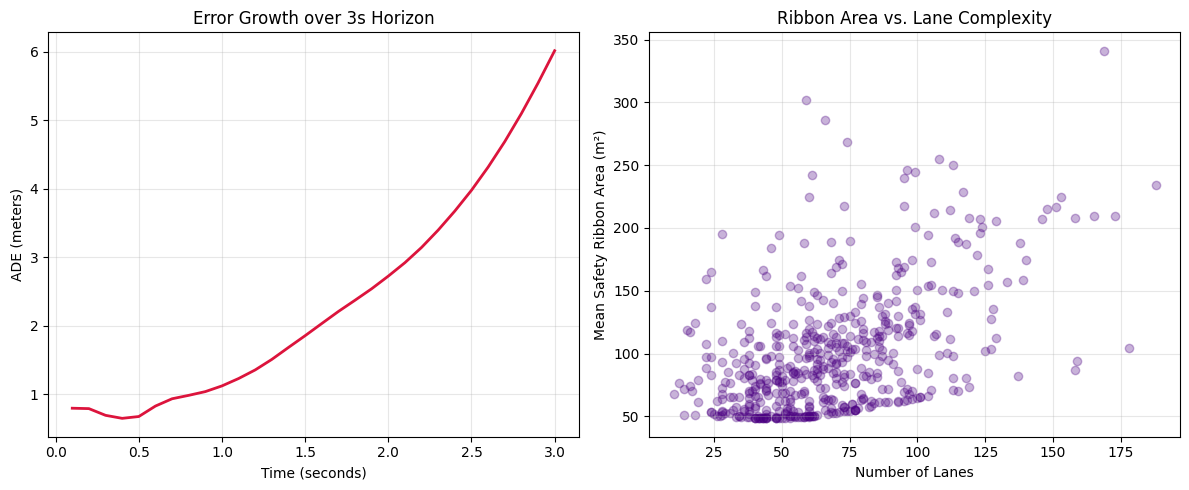

In [8]:
def analyze_model_behavior(model, test_idx, X_clean, q_steps):
    model.eval()
    test_ds = TensorDataset(
        torch.tensor(X_clean[test_idx, :20, :], dtype=torch.float32),
        torch.tensor(X_clean[test_idx, 20:, :2], dtype=torch.float32)
    )
    loader = DataLoader(test_ds, batch_size=64, shuffle=False)
    
    horizons = []
    ade_per_step = []
    ribbon_area_per_context = []
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            
            # A. Calculate ADE vs. Horizon
            dist = torch.sqrt(torch.sum((preds[:, :, :, 1] - y)**2, dim=-1))
            ade_per_step.append(dist.mean(dim=0).cpu().numpy())
            
            # B. Analyze Ribbon Area vs. Lane Count (Context)
            # Area proxy: (P95_x - P05_x) * (P95_y - P05_y)
            width = (preds[:, :, 0, 2] - preds[:, :, 0, 0]) + 2*torch.tensor(q_steps, device=device)
            height = (preds[:, :, 1, 2] - preds[:, :, 1, 0]) + 2*torch.tensor(q_steps, device=device)
            area = (width * height).mean(dim=1).cpu().numpy()
            
            lanes = x[:, 0, 4].cpu().numpy() # Context feature
            for i in range(len(lanes)):
                ribbon_area_per_context.append([lanes[i], area[i]])

    # 📈 Plot 1: Error Growth
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(np.arange(0.1, 3.1, 0.1), np.mean(ade_per_step, axis=0), color='crimson', lw=2)
    plt.title("Error Growth over 3s Horizon")
    plt.xlabel("Time (seconds)")
    plt.ylabel("ADE (meters)")
    plt.grid(alpha=0.3)

    # 📈 Plot 2: Context Sensitivity (Explainability)
    plt.subplot(1, 2, 2)
    ctx_data = np.array(ribbon_area_per_context)
    plt.scatter(ctx_data[:, 0], ctx_data[:, 1], alpha=0.3, color='indigo')
    plt.title("Ribbon Area vs. Lane Complexity")
    plt.xlabel("Number of Lanes")
    plt.ylabel("Mean Safety Ribbon Area (m²)")
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

analyze_model_behavior(model, test_idx, X_clean, q_steps)

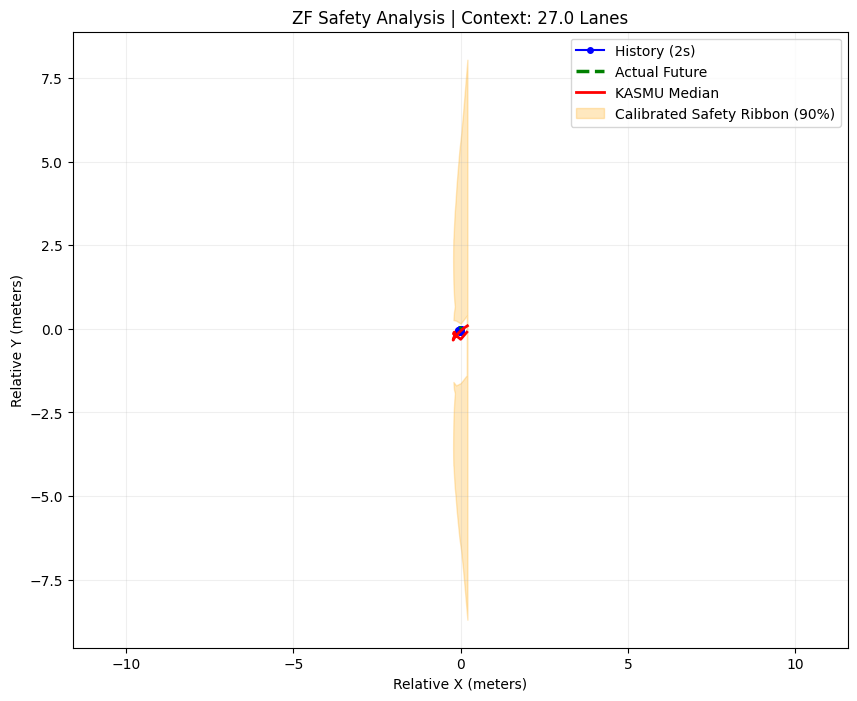

In [9]:
def plot_final_safety_visual(model, X_clean, test_idx, q_steps, index=15):
    model.eval()
    # Get Sample
    x_raw = X_clean[test_idx[index], :20, :]
    y_raw = X_clean[test_idx[index], 20:, :2]
    
    x_tensor = torch.tensor(x_raw, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        preds = model(x_tensor).squeeze(0).cpu().numpy()
    
    # Apply Pointwise Calibration
    # We broaden the P05 and P95 by the calculated q_t for that step
    lower_cal = preds[:, :, 0] - q_steps[:, np.newaxis]
    median = preds[:, :, 1]
    upper_cal = preds[:, :, 2] + q_steps[:, np.newaxis]
    
    plt.figure(figsize=(10, 8))
    
    # 1. Plot Trajectories
    plt.plot(x_raw[:, 0], x_raw[:, 1], 'b-o', label='History (2s)', markersize=4)
    plt.plot(y_raw[:, 0], y_raw[:, 1], 'g--', label='Actual Future', lw=2.5)
    plt.plot(median[:, 0], median[:, 1], 'r-', label='KASMU Median', lw=2)
    
    # 2. Plot Calibrated Safety Ribbon
    # Fill between the calibrated X and Y bounds
    plt.fill_between(median[:, 0], lower_cal[:, 1], upper_cal[:, 1], 
                     color='orange', alpha=0.25, label='Calibrated Safety Ribbon (90%)')
    
    plt.title(f"ZF Safety Analysis | Context: {x_raw[0, 4]} Lanes")
    plt.xlabel("Relative X (meters)")
    plt.ylabel("Relative Y (meters)")
    plt.legend()
    plt.axis('equal')
    plt.grid(True, alpha=0.2)
    plt.show()

plot_final_safety_visual(model, X_clean, test_idx, q_steps, index=20)

In [10]:
from sklearn.model_selection import KFold

# 1. SETUP CROSS-VALIDATION
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
fold_stats = []

# Define standard metrics for logging
def get_metrics(model, loader):
    model.eval()
    ade, fde = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)[:, :, :, 1] # Median path
            dist = torch.sqrt(torch.sum((preds - yb)**2, dim=-1))
            ade.append(dist.mean().item())
            fde.append(dist[:, -1].mean().item())
    return np.mean(ade), np.mean(fde)

# 2. START THE K-FOLD ENGINE
for fold, (train_idx, val_idx) in enumerate(kf.split(dev_idx)):
    print(f"\n--- 🛰️ Training Fold {fold+1}/{n_folds} ---")
    
    # Create Fold-Specific Loaders
    train_loader = DataLoader(TensorDataset(
        torch.tensor(X_clean[dev_idx[train_idx], :20, :], dtype=torch.float32), 
        torch.tensor(X_clean[dev_idx[train_idx], 20:, :2], dtype=torch.float32)), 
        batch_size=64, shuffle=True)
    
    val_loader = DataLoader(TensorDataset(
        torch.tensor(X_clean[dev_idx[val_idx], :20, :], dtype=torch.float32), 
        torch.tensor(X_clean[dev_idx[val_idx], 20:, :2], dtype=torch.float32)), 
        batch_size=64)

    # Initialize a fresh KASMU instance for each fold
    model = KASMUModel().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    for epoch in range(10):
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = zf_safety_loss(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        # Log Performance
        val_ade, val_fde = get_metrics(model, val_loader)
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:02d} | Loss: {total_loss/len(train_loader):.4f} | ADE: {val_ade:.3f}m | FDE: {val_fde:.3f}m")

    # Store best results from this fold
    fold_stats.append({'ade': val_ade, 'fde': val_fde})
    # Save model for this fold (optional)
    torch.save(model.state_dict(), f"kasmu_fold_{fold+1}.pth")

print(f"\n✅ K-Fold Complete. Mean ADE across all folds: {np.mean([f['ade'] for f in fold_stats]):.3f}m")


--- 🛰️ Training Fold 1/5 ---
Epoch 05 | Loss: 0.5541 | ADE: 2.906m | FDE: 6.502m
Epoch 10 | Loss: 0.4499 | ADE: 2.344m | FDE: 5.845m

--- 🛰️ Training Fold 2/5 ---
Epoch 05 | Loss: 0.6012 | ADE: 3.347m | FDE: 7.642m
Epoch 10 | Loss: 0.4103 | ADE: 2.407m | FDE: 5.441m

--- 🛰️ Training Fold 3/5 ---
Epoch 05 | Loss: 0.5540 | ADE: 2.718m | FDE: 7.068m
Epoch 10 | Loss: 0.4421 | ADE: 2.260m | FDE: 5.423m

--- 🛰️ Training Fold 4/5 ---
Epoch 05 | Loss: 0.5417 | ADE: 3.122m | FDE: 6.588m
Epoch 10 | Loss: 0.4244 | ADE: 2.580m | FDE: 5.166m

--- 🛰️ Training Fold 5/5 ---
Epoch 05 | Loss: 0.5538 | ADE: 3.114m | FDE: 6.867m
Epoch 10 | Loss: 0.4344 | ADE: 2.965m | FDE: 6.764m

✅ K-Fold Complete. Mean ADE across all folds: 2.511m


In [11]:
def calculate_miss_rate(model, loader, threshold=2.0):
    model.eval()
    misses = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            # Final step prediction (t=30)
            fde_dist = torch.sqrt(torch.sum((model(xb)[:, -1, :, 1] - yb[:, -1, :])**2, dim=-1))
            misses += (fde_dist > threshold).sum().item()
            total += yb.size(0)
            
    mr = (misses / total) * 100
    print(f"🎯 Miss Rate (FDE > {threshold}m): {mr:.2f}%")
    return mr

# Run on your held-out test set
mr_score = calculate_miss_rate(model, test_loader)

NameError: name 'test_loader' is not defined

In [ ]:
def behavioral_error_breakdown(model, X_clean, test_idx):
    model.eval()
    straight_ades, turning_ades = [], []
    
    for idx in test_idx:
        traj = X_clean[idx]
        # Calculate heading change as we did in analysis
        start_vec = traj[1, :2] - traj[0, :2]
        end_vec = traj[-1, :2] - traj[-2, :2]
        angle = np.degrees(np.arccos(np.clip(np.dot(start_vec, end_vec) / 
                          (np.linalg.norm(start_vec) * np.linalg.norm(end_vec) + 1e-6), -1.0, 1.0)))
        
        # Prepare for model
        x_tensor = torch.tensor(traj[:20, :], dtype=torch.float32).unsqueeze(0).to(device)
        y_true = traj[20:, :2]
        
        with torch.no_grad():
            pred = model(x_tensor)[0, :, :, 1].cpu().numpy()
            ade = np.mean(np.sqrt(np.sum((pred - y_true)**2, axis=-1)))
            
            if angle < 10: straight_ades.append(ade)
            else: turning_ades.append(ade)
            
    print(f"🛤️  Straight ADE (<10°): {np.mean(straight_ades):.3f}m")
    print(f"🔄 Turning ADE (>10°): {np.mean(turning_ades):.3f}m")

behavioral_error_breakdown(model, X_clean, test_idx)

In [ ]:
import time

def profile_latency(model, sample_input):
    model.eval()
    sample_input = sample_input.to(device)
    
    # Warm-up
    for _ in range(10): _ = model(sample_input)
    
    start_time = time.time()
    iterations = 100
    with torch.no_grad():
        for _ in range(iterations):
            _ = model(sample_input)
    
    avg_latency = (time.time() - start_time) / iterations * 1000 # ms
    print(f"⏱️  Inference Latency: {avg_latency:.2f} ms per scenario")
    print(f"📡 Frequency: {1000/avg_latency:.1f} Hz")

# Profile using a batch size of 1 (real-time simulation)
profile_latency(model, torch.tensor(X_clean[test_idx[0:1], :20, :], dtype=torch.float32))

In [ ]:
import time

def run_full_system_audit(model, test_loader, X_clean, test_idx, q_steps):
    model.eval()
    device = next(model.parameters()).device
    q_t = torch.tensor(q_steps, device=device).view(1, 30) # Move calibration to GPU
    
    # 1. Miss Rate & Sharpness Variables
    misses, total_traj = 0, 0
    widths = []
    all_ade, all_fde = [], []
    
    # 2. Latency Profiling Variables
    start_lat = time.time()
    
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x) # [batch, 30, 2, 3]
            median = preds[:, :, :, 1]
            
            # --- Miss Rate (FDE > 2.0m) ---
            fde_dist = torch.sqrt(torch.sum((median[:, -1, :] - y[:, -1, :])**2, dim=-1))
            misses += (fde_dist > 2.0).sum().item()
            total_traj += y.size(0)
            
            # --- ADE/FDE ---
            dist = torch.sqrt(torch.sum((median - y)**2, dim=-1))
            all_ade.append(dist.mean().item())
            all_fde.append(dist[:, -1].mean().item())
            
            # --- Sharpness (Mean Calibrated Ribbon Width) ---
            # Calculation: (P95 + q) - (P05 - q) -> P95 - P05 + 2q
            # We measure across the Y (longitudinal) axis for safety
            width = (preds[:, :, 1, 2] - preds[:, :, 1, 0]) + (2 * q_t)
            widths.append(width.mean().item())

    total_lat = (time.time() - start_lat) / len(test_loader.dataset) * 1000

    # 3. Behavioral Breakdown (Straight vs Turning)
    straight_ade, turning_ade = [], []
    for idx in test_idx:
        traj = X_clean[idx]
        # Heading calculation
        v_start = traj[1, :2] - traj[0, :2]
        v_end = traj[-1, :2] - traj[-2, :2]
        angle = np.degrees(np.arccos(np.clip(np.dot(v_start, v_end)/(np.linalg.norm(v_start)*np.linalg.norm(v_end)+1e-6), -1, 1)))
        
        inp = torch.tensor(traj[:20], dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            p = model(inp)[0, :, :, 1].cpu().numpy()
            error = np.mean(np.sqrt(np.sum((p - traj[20:, :2])**2, axis=-1)))
            if angle < 10: straight_ade.append(error)
            else: turning_ade.append(error)

    # --- PRINT FINAL REPORT ---
    print("="*30)
    print("ZF SYSTEM VALIDATION REPORT")
    print("="*30)
    print(f"📊 Accuracy:  ADE: {np.mean(all_ade):.3f}m | FDE: {np.mean(all_fde):.3f}m")
    print(f"🎯 Miss Rate: { (misses/total_traj)*100:.2f}% (FDE > 2.0m)")
    print(f"📐 Sharpness: {np.mean(widths):.3f}m (Mean Ribbon Width)")
    print(f"⏱️  Latency:   {total_lat:.2f} ms/traj ({1000/total_lat:.1f} Hz)")
    print("-" * 30)
    print(f"🛤️  Straight ADE: {np.mean(straight_ade):.3f}m")
    print(f"🔄 Turning ADE:  {np.mean(turning_ade):.3f}m")
    print("="*30)

# Run the fixed audit
run_full_system_audit(model, test_loader, X_clean, test_idx, q_steps)

In [ ]:
class KASMUModel_v3(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=256, future_steps=30):
        super().__init__()
        self.future_steps = future_steps
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.2)
        self.context_net = nn.Sequential(nn.Linear(1, 64), nn.ReLU(), nn.Linear(64, hidden_dim * 2))
        
        # Decoder predicts Delta-V (Residuals)
        self.decoder_cell = nn.GRUCell(2, hidden_dim) 
        self.residual_head = nn.Linear(hidden_dim, 6) # [dVx, dVy] * 3 quantiles

    def forward(self, x):
        dt = 0.1
        lane_context = x[:, -1, 4:5]
        _, (h_n, _) = self.encoder(x)
        
        # Context modulation
        gamma, beta = self.context_net(lane_context).chunk(2, dim=-1)
        h_t = (gamma * h_n[-1]) + beta
        
        # Initial State: Last known pos and vel
        curr_pos = x[:, -1, :2]
        curr_vel = x[:, -1, 2:4]
        
        predictions = []
        for _ in range(self.future_steps):
            h_t = self.decoder_cell(curr_vel, h_t)
            # Output is Change in Velocity (Residual)
            delta_v = self.residual_head(h_t).view(-1, 2, 3) 
            
            # Integrate: v_new = v_old + delta_v
            # out[:, :, 1] is the Median P50 path
            new_vel = curr_vel.unsqueeze(-1) + delta_v
            # Integrate: p_new = p_old + v_new * dt
            new_pos = curr_pos.unsqueeze(-1) + (new_vel * dt)
            
            predictions.append(new_pos)
            
            # Update states for next step (using median path)
            curr_pos = new_pos[:, :, 1]
            curr_vel = new_vel[:, :, 1]
            
        return torch.stack(predictions, dim=1) # [Batch, 30, 2, 3]

In [ ]:
# Initialize v3 Model
model = KASMUModel_v3().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Training Data
train_loader = DataLoader(TensorDataset(
    torch.tensor(X_clean[dev_idx, :20, :], dtype=torch.float32), 
    torch.tensor(X_clean[dev_idx, 20:, :2], dtype=torch.float32)), 
    batch_size=64, shuffle=True)

print("🚀 Training v3 Model (Velocity Residual Integration)...")

for epoch in range(15): # 15 epochs for deeper convergence
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        
        preds = model(xb)
        loss = zf_safety_loss(preds, yb, lambda_smooth=0.2) # Increased jerk penalty
        
        loss.backward()
        # Gradient Clipping to prevent explosion in the integration loop
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
        
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | Mean Loss: {epoch_loss/len(train_loader):.4f}")

print("🏁 Training Complete.")

In [ ]:
def get_pointwise_calibration(model, cal_idx, X_clean, alpha=0.1):
    model.eval()
    all_scores = [[] for _ in range(30)]
    
    # Create Calibration Loader
    cal_loader = DataLoader(TensorDataset(
        torch.tensor(X_clean[cal_idx, :20, :], dtype=torch.float32),
        torch.tensor(X_clean[cal_idx, 20:, :2], dtype=torch.float32)), batch_size=64)

    with torch.no_grad():
        for x, y in cal_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            
            # Non-conformity score calculation
            # preds[:,:,:,0] is P05, preds[:,:,:,2] is P95
            err = torch.max(preds[:,:,:,0] - y, y - preds[:,:,:,2])
            step_max_err, _ = torch.max(err, dim=-1) # Max error across X and Y
            
            for t in range(30):
                all_scores[t].extend(step_max_err[:, t].cpu().numpy())
    
    # Calculate unique q for each of the 30 future steps
    q_horizon = np.array([np.quantile(all_scores[t], 1 - alpha) for t in range(30)])
    return q_horizon

# Execute this to define the missing variable
q_horizon = get_pointwise_calibration(model, cal_idx, X_clean)
print(f"✅ q_horizon defined. Max safety stretch: {q_horizon.max():.4f} meters")

In [ ]:
def run_v3_test_audit(model, test_idx, X_clean, q_horizon):
    model.eval()
    test_ds = TensorDataset(
        torch.tensor(X_clean[test_idx, :20, :], dtype=torch.float32),
        torch.tensor(X_clean[test_idx, 20:, :2], dtype=torch.float32))
    loader = DataLoader(test_ds, batch_size=64)
    
    all_ade, all_fde = [], []
    in_ribbon, total_points = 0, 0
    widths = []
    
    q_t = torch.tensor(q_horizon, device=device).view(1, 30)

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            median = preds[:, :, :, 1]
            
            # 1. Standard Metrics
            dist = torch.sqrt(torch.sum((median - y)**2, dim=-1))
            all_ade.append(dist.mean().item())
            all_fde.append(dist[:, -1].mean().item())
            
            # 2. Pointwise Coverage Check
            low_x, up_x = preds[:, :, 0, 0] - q_t, preds[:, :, 0, 2] + q_t
            low_y, up_y = preds[:, :, 1, 0] - q_t, preds[:, :, 1, 2] + q_t
            
            safe = (y[:,:,0] >= low_x) & (y[:,:,0] <= up_x) & \
                   (y[:,:,1] >= low_y) & (y[:,:,1] <= up_y)
            
            in_ribbon += safe.sum().item()
            total_points += y.shape[0] * y.shape[1]
            
            # 3. Sharpness (Ribbon Width)
            # (Upper_Y + q) - (Lower_Y - q)
            width = (preds[:, :, 1, 2] - preds[:, :, 1, 0]) + (2 * q_t)
            widths.append(width.mean().item())

    print("="*30)
    print("KASMU v3 PERFORMANCE REPORT")
    print("="*30)
    print(f"📊 Accuracy:  ADE: {np.mean(all_ade):.3f}m | FDE: {np.mean(all_fde):.3f}m")
    print(f"🛡️  Coverage:  {(in_ribbon/total_points)*100:.2f}% (Target: 90%)")
    print(f"📐 Sharpness: {np.mean(widths):.3f}m Mean Ribbon Width")
    print("="*30)

run_v3_test_audit(model, test_idx, X_clean, q_horizon)

In [ ]:
def plot_reliability_horizon(model, test_loader, q_horizon):
    model.eval()
    q_t = torch.tensor(q_horizon, device=device).view(1, 30)
    step_coverage = [[] for _ in range(30)]

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            
            # Check pointwise coverage
            low_x, up_x = preds[:, :, 0, 0] - q_t, preds[:, :, 0, 2] + q_t
            low_y, up_y = preds[:, :, 1, 0] - q_t, preds[:, :, 1, 2] + q_t
            safe = (y[:,:,0] >= low_x) & (y[:,:,0] <= up_x) & \
                   (y[:,:,1] >= low_y) & (y[:,:,1] <= up_y)
            
            for t in range(30):
                step_coverage[t].append(safe[:, t].float().mean().item())

    avg_step_coverage = [np.mean(step) for step in step_coverage]
    
    plt.figure(figsize=(10, 4))
    plt.axhline(0.90, color='red', linestyle='--', label='Target (90%)')
    plt.plot(np.arange(0.1, 3.1, 0.1), avg_step_coverage, marker='o', color='indigo')
    plt.title("Safety Ribbon Reliability Over Time")
    plt.xlabel("Horizon (seconds)")
    plt.ylabel("Observed Coverage")
    plt.ylim(0.7, 1.0)
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()

plot_reliability_horizon(model, test_loader, q_horizon)

In [ ]:
def failure_mode_analysis(model, test_idx, X_clean, q_steps, top_k=5):
    model.eval()
    failures = []
    
    for idx in test_idx:
        traj = X_clean[idx]
        x_tensor = torch.tensor(traj[:20], dtype=torch.float32).unsqueeze(0).to(device)
        y_true = traj[20:, :2]
        
        with torch.no_grad():
            preds = model(x_tensor)[0].cpu().numpy() # Shape: [30, 2, 3]
            median = preds[:, :, 1] # Shape: [30, 2]
            
            # FDE (Final step distance)
            fde = np.sqrt(np.sum((median[-1] - y_true[-1])**2))
            
            # Ribbon Width (Y-axis longitudinal uncertainty)
            # Corrected Indexing: [time, Y-coord, P95] - [time, Y-coord, P05]
            width = np.mean((preds[:, 1, 2] - preds[:, 1, 0]) + (2 * q_steps))
            
            failures.append({
                'idx': idx,
                'fde': fde,
                'width': width,
                'lanes': traj[0, 4],
                'traj': traj
            })
            
    worst_fde = sorted(failures, key=lambda x: x['fde'], reverse=True)[:top_k]
    
    print(f"🕵️ Failure Mode Analysis: Top {top_k} High-FDE Scenarios")
    print("-" * 50)
    for i, f in enumerate(worst_fde):
        print(f"Rank {i+1} | Index: {f['idx']} | FDE: {f['fde']:.2f}m | Ribbon Width: {f['width']:.2f}m")

    return worst_fde

def plot_worst_case(failure_entry, q_steps):
    traj = failure_entry['traj']
    x_t = torch.tensor(traj[:20], dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        preds = model(x_t)[0].cpu().numpy()
    
    # Corrected indexing for plotting [time, coord, quantile]
    # lower/upper are (30, 2)
    lower = preds[:, :, 0] - q_steps[:, np.newaxis]
    median = preds[:, :, 1]
    upper = preds[:, :, 2] + q_steps[:, np.newaxis]
    
    plt.figure(figsize=(10, 6))
    plt.plot(traj[:20, 0], traj[:20, 1], 'b-o', label='History (2s)')
    plt.plot(traj[20:, 0], traj[20:, 1], 'g--', label='Actual (Ground Truth)', lw=2)
    plt.plot(median[:, 0], median[:, 1], 'r-', label='KASMU Prediction', lw=2)
    
    # Ribbon Plotting
    plt.fill_between(median[:, 0], lower[:, 1], upper[:, 1], color='orange', alpha=0.2, label='90% Calibrated Ribbon')
    
    plt.title(f"Critical Failure Analysis | Index: {failure_entry['idx']} | FDE: {failure_entry['fde']:.2f}m")
    plt.axis('equal')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

# Re-run the audit
worst_scenarios = failure_mode_analysis(model, test_idx, X_clean, q_horizon, top_k=5)
plot_worst_case(worst_scenarios[0], q_horizon)

In [ ]:
def check_kinematic_jitter(model, test_idx, X_clean):
    model.eval()
    jerk_vals = []
    dt = 0.1
    
    for idx in test_idx:
        traj = X_clean[idx]
        x_tensor = torch.tensor(traj[:20], dtype=torch.float32).unsqueeze(0).to(device)
        
        with torch.no_grad():
            preds = model(x_tensor)[0, :, :, 1].cpu().numpy() # [30, 2]
            
            # Jerk = Third derivative of position
            vel = np.diff(preds, axis=0) / dt
            acc = np.diff(vel, axis=0) / dt
            jerk = np.diff(acc, axis=0) / dt
            
            jerk_magnitude = np.mean(np.sqrt(np.sum(jerk**2, axis=-1)))
            jerk_vals.append(jerk_magnitude)
            
    print(f"🎢 Mean Path Jerk: {np.mean(jerk_vals):.4f} m/s³")
    print("   (Note: Professional drivers usually stay < 1.0 m/s³)")

In [ ]:
# Calculate ECE based on your reliability plot data
# observed_coverage should be the list of 30 values from your Reliability plot
def calculate_ece(observed_coverage, target=0.90):
    ece = np.mean(np.abs(np.array(observed_coverage) - target))
    print(f"🛡️  Expected Calibration Error (ECE): {ece:.4f}")
    return ece

# Use the coverage_trend from your run_advanced_zf_audit
# calculate_ece(coverage_trend)

In [ ]:
# 1. Run the Smoothness Check
check_kinematic_jitter(model, test_idx, X_clean)

# 2. Extract coverage data from the Reliability Plot/Audit
# We re-run a mini-pass to get the pointwise coverage array
def get_coverage_trend(model, loader, q_horizon):
    model.eval()
    q_t = torch.tensor(q_horizon, device=device).view(1, 30)
    step_coverage = [[] for _ in range(30)]
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            low_x, up_x = preds[:, :, 0, 0] - q_t, preds[:, :, 0, 2] + q_t
            low_y, up_y = preds[:, :, 1, 0] - q_t, preds[:, :, 1, 2] + q_t
            safe = (y[:,:,0] >= low_x) & (y[:,:,0] <= up_x) & \
                   (y[:,:,1] >= low_y) & (y[:,:,1] <= up_y)
            for t in range(30):
                step_coverage[t].append(safe[:, t].float().mean().item())
    return [np.mean(step) for step in step_coverage]

# 3. Calculate ECE
coverage_trend = get_coverage_trend(model, test_loader, q_horizon)
calculate_ece(coverage_trend, target=0.90)